In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report

In [10]:
data = pd.read_csv('Final_data/emotions.csv')

In [ ]:
data

# mean_0_a  mean_1_a  mean_2_a  mean_3_a  mean_4_a  mean_d_0_a  \
0          4.620      30.3    -356.0     15.60      26.3       1.070   
1         28.800      33.1      32.0     25.80      22.8       6.550   
2          8.900      29.4    -416.0     16.70      23.7      79.900   
3         14.900      31.6    -143.0     19.80      24.3      -0.584   
4         28.300      31.3      45.2     27.30      24.5      34.800   
...          ...       ...       ...       ...       ...         ...   
2127      32.400      32.2      32.2     30.80      23.4       1.640   
2128      16.300      31.3    -284.0     14.30      23.9       4.200   
2129      -0.547      28.3    -259.0     15.80      26.7       9.080   
2130      16.800      19.9    -288.0      8.34      26.0       2.460   
2131      27.000      32.0      31.8     25.00      28.9       4.990   

      mean_d_1_a  mean_d_2_a  mean_d_3_a  mean_d_4_a  mean_d_0_a2  \
0          0.411     -15.700       2.060        3.15         2.15   
1          1.680       2.880       3.830       -4.82        25.60   
2          3.360      90.200      89.900        2.03         7.75   
3         -0.284       8.820       2.300       -1.97        17.30   
4         -5.790       3.060      41.400        5.52        26.10   
...          ...         ...         ...         ...          ...   
2127      -2.030       0.647      -0.121       -1.10        33.30   
2128       1.090       4.460       4.720        6.63       -39.40   
2129       6.900      12.700       2.030        4.64        -1.26   
2130       1.580     -16.000       1.690        4.74        20.90   
2131       1.950       6.210       3.490       -3.51        27.50   

      mean_d_1_a2  mean_d_2_a2  mean_d_3_a2  mean_d_4_a2  mean_d_5_a  \
0            29.5       -353.0        14.40         21.5        5.98   
1            32.8         29.6        21.50         17.4       25.50   
2            30.1       -441.0         9.89         25.3      -68.90   
3            32.0       -148.0        20.40         22.8       13.20   
4            34.3         43.7        23.70         20.6       -3.87   
...           ...          ...          ...          ...         ...   
2127         33.4         31.0        32.30         18.6       30.00   
2128         32.5       -287.0       -42.10         19.2       66.40   
2129         27.2       -254.0        12.50         23.1       -8.82   
2130         21.1       -285.0        11.00         18.8       10.50   
2131         32.1         29.8        24.80         31.3       21.60   

      mean_d_6_a  mean_d_7_a  mean_d_8_a  mean_d_9_a  mean_d_10_a  \
0           30.7      -343.0       14.70        27.9        3.170   
1           31.7        31.5       26.20        32.9       31.800   
2           25.3      -481.0      -65.40        20.0       79.800   
3           31.5      -147.0       16.90        27.7       15.700   
4           34.1        43.7      -10.00        22.9       59.400   
...          ...         ...         ...         ...          ...   
2127        33.0        32.6       29.50        29.1       32.000   
2128        29.0      -286.0       64.50        22.0       19.400   
2129        22.4      -275.0       17.10        25.6        0.367   
2130        17.2      -275.0        4.09        28.4       19.500   
2131        30.0        27.7       21.80        30.0       30.000   

      mean_d_11_a  mean_d_12_a  mean_d_13_a  mean_d_14_a  mean_d_15_a  \
0            32.2       -368.0        15.90         36.4         7.08   
1            33.1         33.2        28.50         26.8        32.40   
2            31.0       -408.0        91.90         29.5        18.80   
3            30.7       -142.0        20.70         22.8        13.60   
4            26.7         60.3        64.70         26.9        32.30   
...           ...          ...          ...          ...          ...   
2127         29.9         32.6        28.50         24.9        34.50   
2128         31.1       -280.0    

In [11]:
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold


selector = SelectKBest(mutual_info_classif, k=5)

pipeline = Pipeline([
    ('scaler',    StandardScaler()),
    ('selector',  selector),
    ('clf',       SVC(kernel='rbf', C=1.0, gamma='scale')),
])


In [60]:
data['label'].value_counts()

NEUTRAL     716
NEGATIVE    708
POSITIVE    708
Name: label, dtype: int64

In [7]:
label_mapping = {'NEGATIVE': 0, 'NEUTRAL': 1, 'POSITIVE': 2}

In [12]:
def preprocess_inputs(df):
  df = df.copy()
    
  df['label'] = df['label'].replace(label_mapping)
    
  y = df['label'].copy()
  X = df.drop('label', axis=1).copy()
    
  X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=123)
    
  return X_train, X_test, y_train, y_test

In [13]:
X_train, X_test, y_train, y_test = preprocess_inputs(data)

/var/folders/_b/t1t41vkj1vngyhrv0pg1fbg80000gn/T/ipykernel_60520/3624764054.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['label'] = df['label'].replace(label_mapping)


In [14]:
pipeline.fit(X_train, y_train)
selector = pipeline.named_steps['selector']
feature_names = data.columns.tolist()
selected_mask = selector.get_support()
selected_features = [name for name, selected in zip(feature_names, selected_mask) if selected]

In [32]:
selected_features

['mean_2_a', 'covmat_0_a', 'mean_2_b', 'mean_d_12_b', 'covmat_0_b']

In [22]:
X_train, X_test, y_train, y_test = preprocess_inputs(data[selected_features + ['label']])
#X_train, X_test, y_train, y_test = preprocess_inputs(data)

/var/folders/_b/t1t41vkj1vngyhrv0pg1fbg80000gn/T/ipykernel_60520/3624764054.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['label'] = df['label'].replace(label_mapping)


In [35]:
inputs = tf.keras.Input(shape=(X_train.shape[1],))

expand_dims = tf.keras.layers.Lambda(lambda x: tf.expand_dims(x, axis=2))(inputs)
gru = tf.keras.layers.GRU(16, return_sequences=True)(expand_dims)
flatten = tf.keras.layers.Flatten()(gru)
outputs = tf.keras.layers.Dense(3, activation='softmax')(flatten)

model = tf.keras.Model(inputs=inputs, outputs=outputs)
print(model.summary())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 5, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 5, 16)          │           912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           243 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,155 (4.51 KB)

 Trainable params: 1,155 (4.51 KB)

 Non-trainable params: 0 (0.00 B)

None


In [36]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    batch_size=32,
    epochs=50,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )
    ]
)

Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5784 - loss: 0.9289 - val_accuracy: 0.6990 - val_loss: 0.7011
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8156 - loss: 0.5940 - val_accuracy: 0.8227 - val_loss: 0.5150
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8474 - loss: 0.4568 - val_accuracy: 0.8562 - val_loss: 0.4223
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8701 - loss: 0.3842 - val_accuracy: 0.8562 - val_loss: 0.3809
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8709 - loss: 0.3433 - val_accuracy: 0.8662 - val_loss: 0.3552
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8801 - loss: 0.3244 - val_accuracy: 0.8562 - val_loss: 0.3432
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8768 - loss: 0.3155 - val_accuracy: 0.8595 - val_loss: 0.3329
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8910 - loss: 0.2959 - val_accuracy: 0.8662 - val_loss:

In [37]:
model_acc = model.evaluate(X_test, y_test, verbose=0)[1]
print("Test Accuracy: {:.3f}%".format(model_acc * 100))

Test Accuracy: 87.813%


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 743us/step


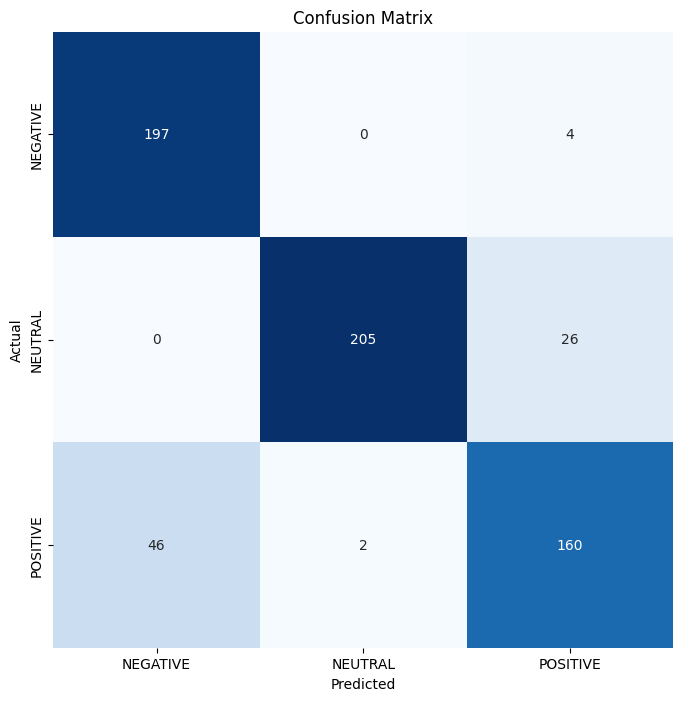

Classification Report:
----------------------
               precision    recall  f1-score   support

    NEGATIVE       0.81      0.98      0.89       201
     NEUTRAL       0.99      0.89      0.94       231
    POSITIVE       0.84      0.77      0.80       208

    accuracy                           0.88       640
   macro avg       0.88      0.88      0.88       640
weighted avg       0.89      0.88      0.88       640



In [38]:
y_pred = np.array(list(map(lambda x: np.argmax(x), model.predict(X_test))))

cm = confusion_matrix(y_test, y_pred)
clr = classification_report(y_test, y_pred, target_names=label_mapping.keys())

plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True, vmin=0, fmt='g', cbar=False, cmap='Blues')
plt.xticks(np.arange(3) + 0.5, label_mapping.keys())
plt.yticks(np.arange(3) + 0.5, label_mapping.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:\n----------------------\n", clr)

In [34]:
data[selected_features + ['label']]

,mean_2_a,covmat_0_a,mean_2_b,mean_d_12_b,covmat_0_b,label
0,-356.0,20400.0,-351.0,-344.0,22300.0,NEGATIVE
1,32.0,25.7,34.5,35.5,31.6,NEUTRAL
2,-416.0,35200.0,-342.0,-291.0,26100.0,POSITIVE
3,-143.0,4430.0,-111.0,-121.0,3960.0,POSITIVE
4,45.2,373.0,84.5,167.0,265.0,NEUTRAL
...,...,...,...,...,...,...
2127,32.2,16.3,32.9,33.5,15.8,NEUTRAL
2128,-284.0,15300.0,-284.0,-284.0,14200.0,POSITIVE
2129,-259.0,12000.0,-234.0,-221.0,11300.0,NEGATIVE
2130,-288.0,13400.0,-288.0,-281.0,15100.0,NEGATIVE
